<a href="https://colab.research.google.com/github/Matheus-Melo-dos-Santos/DIP-2026.2/blob/main/01_image_loader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ImageLoader: carregamento de imagens

Este notebook apresenta o ImageLoader, responsável por abrir imagens locais para as atividades de Processamento Digital de Imagens.

Ao final, você conseguirá carregar uma imagem colorida, uma versão em escala de cinza e uma sequência de imagens.

## 1. Instalar a biblioteca

No Colab, instale a versão mais recente diretamente do repositório.

In [1]:
%pip install -q "git+https://github.com/tfvieira/dip-2026-2.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 MB 15.6 MB/s eta 0:00:00


## 2. Baixar a imagem da disciplina

A função download_course_image localiza a imagem pública pelo nome e devolve seu caminho local. O ImageLoader recebe esse caminho; ele não busca arquivos no Google Drive.

In [2]:
from dip_toolkit import download_course_image
from dip_toolkit.modules.image_loader import ImageLoader

color_image_path = download_course_image(
    "astronaut.png",
    output_dir="/content/dip_images",
)
gray_image_path = download_course_image(
    "cameraman_original.png",
    output_dir="/content/dip_images",
)
loader = ImageLoader()
print("Imagem colorida:", color_image_path)
print("Imagem em escala de cinza:", gray_image_path)

Downloading...
From: https://drive.google.com/uc?id=1GMEaPminTwxnS4rVcE2VqHL9tMA-HPyP
To: /content/dip_images/astronaut.png
100%|██████████| 465k/465k [00:00<00:00, 96.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1o6l3ppBUyeRfRpiQ4ODqOR1N1UeETVIo
To: /content/dip_images/cameraman_original.png
100%|██████████| 133k/133k [00:00<00:00, 60.3MB/s]

Imagem colorida: /content/dip_images/astronaut.png
Imagem em escala de cinza: /content/dip_images/cameraman_original.png


## 3. Carregar e exibir uma imagem colorida

O OpenCV lê imagens coloridas no formato BGR. Para exibi-las corretamente com Matplotlib, convertemos a imagem para RGB.

Formato: (512, 512, 3)
Tipo: uint8


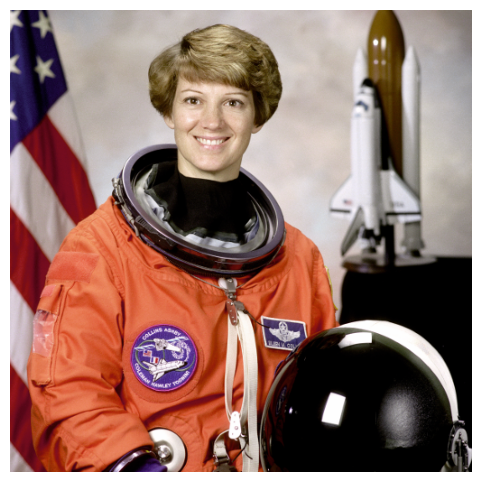

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt

image_color = loader.load_image(color_image_path)
image_rgb = cv.cvtColor(image_color, cv.COLOR_BGR2RGB)

print("Formato:", image_color.shape)
print("Tipo:", image_color.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

## 4. Carregar em escala de cinza

Use flags=cv.IMREAD_GRAYSCALE quando a atividade precisar de uma única intensidade por pixel.

Formato em escala de cinza: (512, 512)


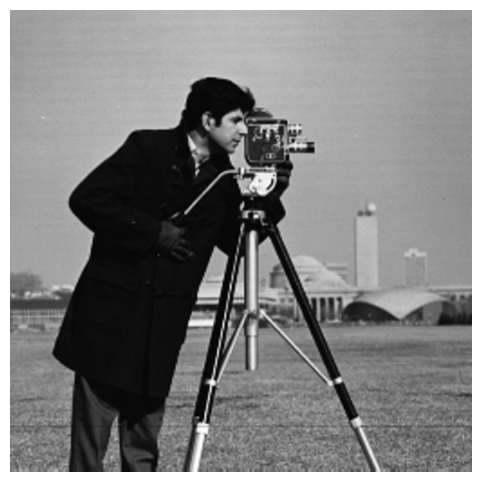

In [12]:
image_gray = loader.load_image(
    gray_image_path,
    flags=cv.IMREAD_GRAYSCALE,
)

print("Formato em escala de cinza:", image_gray.shape)

plt.figure(figsize=(6, 6))
plt.imshow(image_gray, cmap="gray")
plt.axis("off")
plt.show()

## 5. Carregar uma sequência ou um diretório

load_images preserva a ordem da sequência informada. Já load_images_from_directory considera somente extensões de imagem suportadas e retorna os arquivos em ordem alfabética.

In [5]:
sequence = loader.load_images([color_image_path, gray_image_path])
directory_images = loader.load_images_from_directory(color_image_path.parent)

print("Imagens da sequência:", len(sequence))
print("Imagens no diretório:", len(directory_images))

Imagens da sequência: 2
Imagens no diretório: 2


## Exercício

Altere o modo de leitura da imagem para cv.IMREAD_UNCHANGED e compare o formato retornado. Em seguida, experimente informar um caminho inexistente e observe a mensagem de erro.

**Solução**

Formato em escala de cinza: (512, 512)


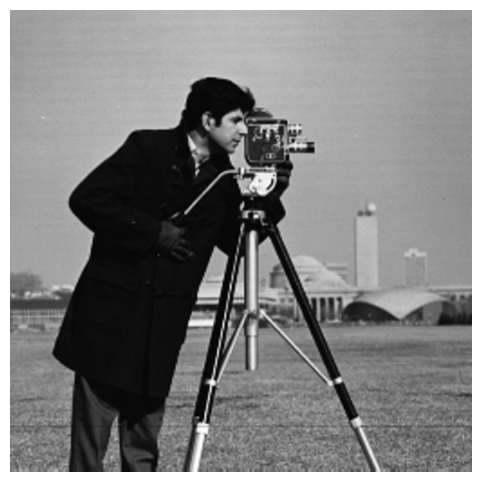

In [14]:
image_gray_unchanged = loader.load_image(
    gray_image_path,
    cv.IMREAD_UNCHANGED
)

print("Formato em escala de cinza:", image_gray_unchanged.shape)

plt.figure(figsize=(6, 6))
plt.imshow(image_gray_unchanged, cmap='gray')
plt.axis("off")
plt.show()


Formato em escala: (512, 512, 3)
Tipo: uint8


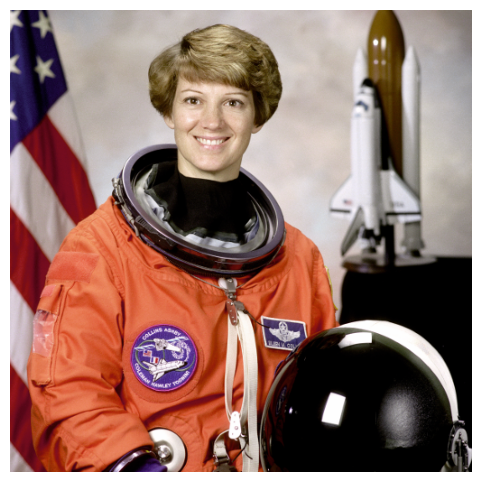

In [19]:
image_color_unchanged = loader.load_image(
    color_image_path,
    cv.IMREAD_UNCHANGED
)
image_unchanged_rgb = cv.cvtColor(image_color_unchanged, cv.COLOR_BGR2RGB)
print("Formato em escala:", image_color_unchanged.shape)
print("Tipo:", image_color_unchanged.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(image_unchanged_rgb)
plt.axis("off")
plt.show()


In [20]:
wrong_path = '/content/images/tmp.png'

image_color_unchanged = loader.load_image(
    wrong_path,
    cv.IMREAD_UNCHANGED
)

FileNotFoundError: Arquivo não encontrado: /content/images/tmp.png